**Notebook Feito por:** MSc. Eng. Paulo de Souza Silva  
**Data:** Agosto de 2026  
**Conteúdo retirado e adaptado de livros e artigos sobre Galerkin Descontínuo**  
**Agradecimentos:** Um agradecimento ao Prof. Dr. Alberto Nogueira pela disponibilização dos scripts em Python para DG 1D

# **Aula 07 - Projeção de Fluxos**

## **Introdução**

Com base na equação que estamos avaliando desde a **aula 00**, seu formato matricial é dado conforme:

$$
\underbrace{J_e \left[\int_{-1}^{1} \phi_i \phi_j d \xi \right]}_{\text{Jacobiano e Matriz de Massa} \ \mathcal{M}}
\dfrac{\partial}{\partial t} \begin{Bmatrix} c_0 \\ c_1 \\ \vdots \\ c_P \end{Bmatrix} =
\underbrace{\int_{-1}^{1} f \dfrac{\partial}{\partial \xi} \begin{Bmatrix} \phi_0 \\ \phi_1 \\ \vdots \\ \phi_P \end{Bmatrix} d \xi }_{\text{Fluxo, Matriz de Derivação} \ \mathcal{D} \ \text{e Rigidez} \ \mathcal{S}} -
\underbrace{\tilde{f}_{e,e+1} \begin{Bmatrix} \phi^+_0 \\ \phi^+_1 \\ \vdots \\ \phi^+_P \end{Bmatrix} +
\tilde{f}_{e-1,e}\begin{Bmatrix} \phi^-_0 \\ \phi^-_1 \\ \vdots \\ \phi^-_P \end{Bmatrix}}_{\text{Fluxos nas Fronteiras}}
$$

mediante ao que debatemos até então, nos falta avaliar o fluxo que acompanha a rigidez e o que é avaliado na fronteira.

No encontro anterior, enquanto construíamos a matriz de rigidez, fizemos manipulações a fim de separar o fluxo do problema e isolar o cálculo de $\mathcal{S}$, neste vamos entender como recuperar, por meio de **projeções**, o $f$ que acompanha a matriz de rigidez.

Na próxima aula voltaremos a falar de fluxos mas olhando para diferentes **estratégias de fluxo numérico** no qual vamos aplicarmos à nossa fronteira em conjunto com a função `LiftMatrix`.

> Nessa aula usaremos os arquivos python `mathDG1D.py` (teoria das aulas 01 a 05) e `coreDG1D.py` (teoria da aula 06)


## **Problema da Não-Linearidade**

Leis de conservação são formadas, em sua maioria, por escoamentos não-lineares. Seja a Equação de Burgers Invíscida, cujo fluxo é $f(u) = \frac{u^2}{2}$, as Equações de Euler para dinâmica de gases ou o sistema de *Shallow Water*, a variável conservativa $u$ sofre produtos diretos. 

Se o nosso polinômio aproximador possui grau $N$, ao avaliarmos um fluxo como $u^2$, o resultado matemático passará a ter grau $2N$. 

Se tentarmos integrar esse fluxo utilizando as matrizes de quadratura projetadas estritamente para o grau $N$, cometeremos o **Erro de Aliasing**. 

O conteúdo de alta frequência do polinômio de grau $2N$ será mapeado incorretamente para as baixas frequências do nosso espaço polinomial, o que invariavelmente destrói a estabilidade do solver DG. A solução para este problema é a **Projeção de Galerkin via Superintegração**.

Retomando de forma breve o que vimos no tema da **aula 06**, para o calculo da matriz de rigidez assumimos que o fluxo era dado de forma aproximada por:

$$f(u(\xi)) \approx \sum_{i=0}^{N} \hat{f}_i \phi_i (\xi)$$

e portanto

$$\int_{-1}^1 \sum_{j=0}^{N} \hat{f}_i \phi_i (\xi) \frac{d\phi_j(\xi)}{d\xi} d\xi \Longrightarrow  \sum_{i=0}^{N} \hat{f}_i \left( \int_{-1}^1 \phi_i (\xi) \frac{d\phi_j(\xi)}{d\xi} d\xi \right) = \sum_{i=0}^{N} \hat{f}_i \mathcal{S}_{ij}$$

**Mas por que precisamos dessa aproximação do fluxo no somatório?**

Para entender o problema, vamos imaginar um caso não-linear simples, onde o fluxo físico é dado por 
$$f(u) = \frac{u^2}{2}$$

Vamos supor que estamos trabalhando com um espaço restrito de grau $N=1$. Nossa solução $u(\xi)$ seria descrita por apenas dois termos:

$$u(\xi) = u_0 \phi_0(\xi) + u_1 \phi_1(\xi)$$

Se aplicarmos essa solução diretamente na função de fluxo físico $f(u)$, teremos:

$$f(u) = \frac{1}{2} \left( u_0 \phi_0(\xi) + u_1 \phi_1(\xi) \right)^2$$

$$f(u) = \frac{1}{2} \left( u_0^2 \phi_0^2(\xi) + 2 u_0 u_1 \phi_0(\xi) \phi_1(\xi) + u_1^2 \phi_1^2(\xi) \right)$$

**Note o que aconteceu:** como as nossas funções de base $\phi$ têm grau 1, ao serem multiplicadas entre si ($\phi^2$), o fluxo físico passou a ter grau 2 (ou seja, $2N$). Em problemas mais complexos, esse grau polinomial explode rapidamente! Isso implica em dois problemas:

> **Incompatibilidade Matricial**  
O fluxo resultante precisaria de $2N + 1$ coeficientes para ser representado, formando um vetor de tamanho $(2N+1) \times 1$. Se bem lembrarmos, nossas matrizes pré-calculadas (massa, rigidez, lift) são todas do tipo $(N+1) \times (N+1)$. Tentar multiplicar uma matriz $(N+1) \times (N+1)$ por um vetor de $(2N+1)$ posições simplesmente quebra a regra de multiplicação linear!

> **Aliasing**  
Se olharmos para a integral pura:  $$\int_{-1}^1 f(u(\xi)) \frac{d\phi_j(\xi)}{d\xi} d\xi$$  
Sabemos que $f(u)$, no nosso exemplo, tem grau $2N$ e a derivada da função de teste $\frac{d\phi_j}{d\xi}$ tem grau $N-1$. Isso significa que, se fôssemos calcular a integral exata do fluxo não-linear, estaríamos integrando um polinômio de grau $2N + (N - 1) = \mathbf{3N - 1}$.  
> Os pontos de integração numérica (quadratura de Gauss) que escolhemos na construção do elemento foram dimensionados para integrar perfeitamente polinômios menores (geralmente até $2N-1$ ou $2N$).   
> Se tentarmos forçar a integração de algo com grau $3N-1$ usando esses mesmos pontos, a matemática comete erros de arredondamento sistemáticos. Esse ruído numérico, chamado de **erro de *aliasing***, se acumula e faz a simulação "explodir" em poucos passos de tempo.

Como a nossa matriz de rigidez $\mathcal{S}$ e o nosso elemento computacional foram construídos para suportar apenas polinômios até o grau $N$, nós não conseguimos representar esse fluxo de grau $2N$ de forma exata no nosso sistema.

---



### **Projeção e Super-Integração**

Pelos motivos apresentados anteriormente precisamos forçar o fluxo físico de volta para o nosso espaço restrito de grau $N$. Definimos os coeficientes modais de fluxo projetado $\hat{f}_i$ tais que:

$$f(u_h) \approx \sum_{i=0}^{N} \hat{f}_i \phi_i(\xi)$$

Aplicando o formalismo de Galerkin, exigimos que o resíduo dessa aproximação seja ortogonal à nossa base:

$$\int_{-1}^{1} \left( f(u_h) - \sum_{i} \hat{f}_i \phi_i \right) \phi_j d\xi = 0$$

Separando a soma da integral, recuperamos a **Matriz de Massa** ($\mathcal{M}_{ij}$):

$$\sum_{i} \underbrace{\left( \int_{-1}^{1} \phi_i \phi_j d\xi \right)}_{ \mathcal{M}_{ij} } \hat{f}_i = \underbrace{\int_{-1}^{1} f(u_h) \phi_j d\xi}_{ \mathbf{b}_j }$$

Em formato matricial, o sistema linear local é isolado da seguinte maneira:

$$\boxed{\hat{\mathbf{f}} = \mathcal{M}^{-1} \mathbf{b}}$$

Para evitar o **erro de *aliasing*** na avaliação do vetor $\mathbf{b}$, nós podemos calcular a integral utilizando uma **quadratura de ordem superior** (*Over-integration*). Definimos graus exatos maiores, como $P_{nl} = 3N$, gerando novos pesos $w^{nl}_m$ e pontos $\xi^{nl}_m$ (*nl* vem de não-linear).

$$\mathbf{b}_j = \int_{-1}^{1} f(u_h) \phi_j d\xi = \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_j(\xi^{nl}_m)$$

E aqui temos duas coisas acontecendo:
1. O índice $j$ (Testes): Ele representa as nossas funções de base $\phi_j$. Como estamos em um espaço de grau $N$, nós temos $N+1$ funções de base (de $\phi_0$ até $\phi_N$). É o índice $j$ que define quantas "linhas" o nosso vetor $\mathbf{b}$ vai ter.
2. O índice $m$ (Quadratura): Esse é o índice dos pontos de integração (que vai de $0$ até $3N$). Ele só existe dentro do somatório.

Isso significa que, para calcular uma única posição do vetor $\mathbf{b}$ (digamos, o $b_0$), você vai somar $3N$ termos. Mas no fim do somatório, tudo isso vira apenas um único número escalar.

Se abrirmos o vetor $\mathbf{b}$, ele tem o formato:

$$\mathbf{b} = \begin{bmatrix} b_0 \\ b_1 \\ \vdots \\ b_N \end{bmatrix} =  \begin{bmatrix} \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_0(\xi^{nl}_m) \\ \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_1(\xi^{nl}_m) \\ \vdots \\ \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_N(\xi^{nl}_m) \end{bmatrix}$$

Resumo das dimensões: 
* A matriz $\mathcal{M}^{-1}$ tem tamanho $(N+1) \times (N+1)$.
* O vetor $\mathbf{b}$ tem tamanho $(N+1) \times 1$.
* O resultado $\hat{\mathbf{f}}$ terá tamanho $(N+1) \times 1$.

A super-integração acontecerá de forma "escondida" dentro do cálculo de cada $b_j$. 

A matriz de massa $\mathcal{M}$ (calculada similarmente ao que vimos na aula anterior) nem fica sabendo que usamos mais pontos para montar o $\mathbf{b}$.

---

## **Anatomia da Projeção no Código**

Ao analisarmos *solvers* para múltiplos problemas (Burgers, Shallow Water, Euler), nota-se que todos executam exatamente os mesmos quatro passos computacionais. É aqui que a matemática que acabamos de ver ganha vida no código:

1. **Recuperação (Espaço Modal $\rightarrow$ Espaço Físico):** 
Multiplicamos os coeficientes modais `uhat` pela matriz de base superintegrada `nlpsi` para encontrar a solução física `uh`.
> **Por que fazemos isso?** Nós conhecemos os coeficientes $\hat{u}$ da nossa solução, mas a função de fluxo não-linear exige o valor físico de $u$. Além disso, precisamos desse valor físico exatamente nos novos pontos da malha ($\xi^{nl}_m$) para realizar a super-integração. Matematicamente, estamos avaliando:
> $$u_h(\xi^{nl}_m) = \sum_{i=0}^{N} \hat{u}_i \phi_i(\xi^{nl}_m)$$

---

2. **A Física:** 
A avaliação não-linear ocorre exclusivamente nos pontos físicos através de uma chamada como `fh = fluxo_real(uh)`.
> **Por que fazemos isso?** Com os valores físicos recuperados nos pontos de quadratura superior, nós finalmente aplicamos a lei de conservação do problema real ponto a ponto. Se estivermos resolvendo a Equação de Burgers, por exemplo, o código simplesmente calcula:
> $$f(u_h(\xi^{nl}_m)) = \frac{(u_h(\xi^{nl}_m))^2}{2}$$

---

3. **Montagem de $\mathbf{b}$:** 
Integramos o resultado numericamente, o que em Python geralmente toma a forma de um produto matricial:   

`b = np.dot(nlwi * nlphi.T, fh)`

> **Por que fazemos isso?** Este passo é a execução direta da nossa técnica contra o erro de aliasing. Os pesos `nlwi` representam $w^{nl}_m$, e a matriz transposta `nlphi.T` carrega os valores de $\phi_j(\xi^{nl}_m)$. A multiplicação matricial realiza exatamente o somatório da quadratura de ordem superior:
> $$\mathbf{b}_j = \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_j(\xi^{nl}_m)$$

---

4. **A Projeção (Espaço Físico $\rightarrow$ Espaço Modal):** 
Multiplicamos o vetor `b` pela matriz de massa inversa `InvM` para obter o fluxo final, pronto para uso no operador diferencial.
> **Por que fazemos isso?** O vetor $\mathbf{b}$ contém o resultado da integral exata, mas ainda não representa os coeficientes do nosso espaço polinomial. Para "espremer" esse vetor de volta aos nossos $N+1$ graus de liberdade (resolvendo a incompatibilidade matricial), aplicamos a solução do sistema linear local:
> $$\hat{\mathbf{f}} = \mathcal{M}^{-1} \mathbf{b}$$

> **Nota de Implementação: O Encapsulamento de `ut`**
> Para evitar erros comuns de manipulação de arrays e bugs difíceis de rastrear, nossa função solicita a matriz global `ut` inteira como argumento e cuida da extração dos dados internamente antes de iniciar o Passo 1, executando:
> ```python
> uhat = ut[:, 1:-1, 0].copy()
> ```
> Esse fatiamento prepara o algoritmo:
> * `[:]`: Pega todos os coeficientes modais (de $0$ a $N$).
> * `[1:-1]`: Extrai apenas os elementos internos do domínio, isolando e ignorando as condições de contorno (células fantasmas) nas bordas.
> * `[0]`: Seleciona a variável de estado de interesse.
> * `.copy()`: A peça mais importante! Garante que estamos manipulando uma cópia segura, evitando sobrescrever a solução do passo de tempo atual acidentalmente.

## **Codando a Projeção do Fluxo de forma generalista**

No lugar de criarmos uma função `FluxProjection` diferente para cada física, podemos explorar o Python para encapsular a matemática da projeção, deixando o cálculo físico modular. 

Abaixo, construímos uma função que recebe uma lista de coeficientes (podem ser 1, 2 ou 3 equações acopladas) e uma função auxiliar `FluxFunc` que deve estar associada a física do problema estudado.

In [1]:
import numpy as np
def FluxProjection(ut_list: list, FluxFunc: callable, nlpsi: np.ndarray, nlwi: np.ndarray, InvM: np.ndarray,):
    """
    Projeta o fluxo físico no espaço modal através de uma projeção L2.

    Esta implementação é genérica e suporta um número arbitrário de
    equações (Burgers, Euler, Navier-Stokes, etc.).

    Parâmetros
    ----------
    ut_list : list of ndarray
        Lista contendo as variáveis conservativas. Cada array deve possuir
        formato (Nldof, K+2) ou (Nldof, K+2, nstage).

    FluxFunc : callable
        Função responsável por calcular os fluxos físicos.

    nlpsi : ndarray
        Base modal avaliada nos pontos da quadratura de superintegração.

    nlwi : ndarray
        Pesos da quadratura de superintegração.

    InvM : ndarray
        Diagonal inversa da matriz de massa.

    Retorna
    -------
    ndarray ou list(ndarray)

        Burgers:
            fhat

        Sistemas:
            [fhat1, fhat2, ...]
    """

    # Remove células fantasmas (ghost cells)
    uhat_list = []

    for ut in ut_list:
        if ut.ndim == 3:
            uhat = ut[:, 1:-1, 0]
        elif ut.ndim == 2:
            uhat = ut[:, 1:-1]
        else:
            raise ValueError("Cada variável deve possuir dimensão 2 ou 3.")

        uhat_list.append(uhat)

    uh_list = [nlpsi @ uhat for uhat in uhat_list]   # Reconstrução da solução física
    fh_list = FluxFunc(*uh_list)   # Avaliação dos fluxos físicos

    # Burgers retorna apenas um array
    if not isinstance(fh_list, (list, tuple)):
        fh_list = [fh_list]

    # Verificação de consistência
    if len(fh_list) != len(uh_list):
        raise ValueError(
            f"FluxFunc retornou {len(fh_list)} fluxo(s), "
            f"mas existem {len(uh_list)} variável(is)."
        )

    # Projeção L2
    ProjectionMatrix = nlwi * nlpsi.T
    fhat_list = []

    for fh in fh_list:
        b = ProjectionMatrix @ fh
        fhat = InvM[:, None] * b
        fhat_list.append(fhat)

    # Compatibilidade com problemas escalares
    if len(fhat_list) == 1:
        return fhat_list[0]

    return fhat_list

### **Exemplo de uso da Projeção do Fluxo**

Vamos estudar um exemplo simples, considerando somente o instante inicial (IC) do problema, para termos uma ideia de como ele irá projetar tal instante para diferentes variaveis de entrada

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mathDG1D import jacobi_gauss_quad 
from coreDG1D import MeshGen1D, LegendreBasis, MassMatrix, DMatrix1D, StiffMatrix

# Grau do polinômio e número de elementos
N = 2
K = 5
Nldof = N + 1

# Malha
Nv, VX, EToV = MeshGen1D(K) 

# Quadratura para projeção da condição inicial
xi, wi = jacobi_gauss_quad(P=2*N, alpha=0.0, beta=0.0, quad_type="GL") 
psi = LegendreBasis(N, xi) 

# Quadratura para superintegração
nlxi, nlwi = jacobi_gauss_quad(P=3*N, alpha=0.0, beta=0.0, quad_type="GL") 
nlpsi = LegendreBasis(N, nlxi) 

# Matriz de massa
_, InvM = MassMatrix(Nldof) 

# Matriz de Derivacao, Derivada de Psi e Matriz de rigidez
Dr = DMatrix1D(xi,len(xi))
Dpsi = Dr @ psi
Ss = StiffMatrix(wi,psi,Dpsi)

**Exemplo: Equação de Burgers Invíscida**

A EDP do problema de Burgers invíscido pode ser expressa por:
$$u_t + f_x(u) = 0$$

com $f(u) = 0.5u^2$ e uma possível Condição inicial sendo:
$$u(x,0) = 0.5 + \sin(2\pi x)$$

> O tratamento e as definições de *Condições iniciais (ICs) e de Contorno (BCs)* serão assuntos da **aula 09**

In [3]:
# Fluxo de Burgers
def BurgersFlux(u):
    return 0.5 * u**2

# Condicao Inicial u(x,0)
def InviscidBurgers(xc):
    uxi = 0.5 + np.sin(2.0*np.pi*xc)
    return uxi

# Projeta a condição inicial elemento por elemento
def IC_Burgers(VX,K,Nldof,xi,psi,InvM):
    uhat = np.zeros((Nldof, K))

    for k in range(K):
        xa = VX[k]
        xb = VX[k+1]
        x_quad = 0.5 * (xb - xa) * xi + 0.5 * (xa + xb)  # Pontos de quadratura no elemento físico
        u_quad = InviscidBurgers(x_quad)                 # u na Condição inicial   
        b = np.dot(wi * psi.T, u_quad)                   # Projeção L^2
        uhat[:, k] = InvM * b
    return uhat

# Monta ut 
uhat_burg = IC_Burgers(VX,K,Nldof,xi,psi,InvM)
ut_burg = np.zeros((Nldof, K + 2, 1))
ut_burg[:, 1:-1, 0] = uhat_burg

# Projeção do fluxo 
fhat_burg = FluxProjection(
    ut_list=[ut_burg],
    FluxFunc=BurgersFlux,
    nlpsi=nlpsi,
    nlwi=nlwi,
    InvM=InvM
) 

In [4]:
print(f"Rigidez Shape: {np.shape(Ss)}")

print(f"Fluxo Projetado Shape: {np.shape(fhat_burg)}")

Rigidez Shape: (3, 3)
Fluxo Projetado Shape: (3, 5)


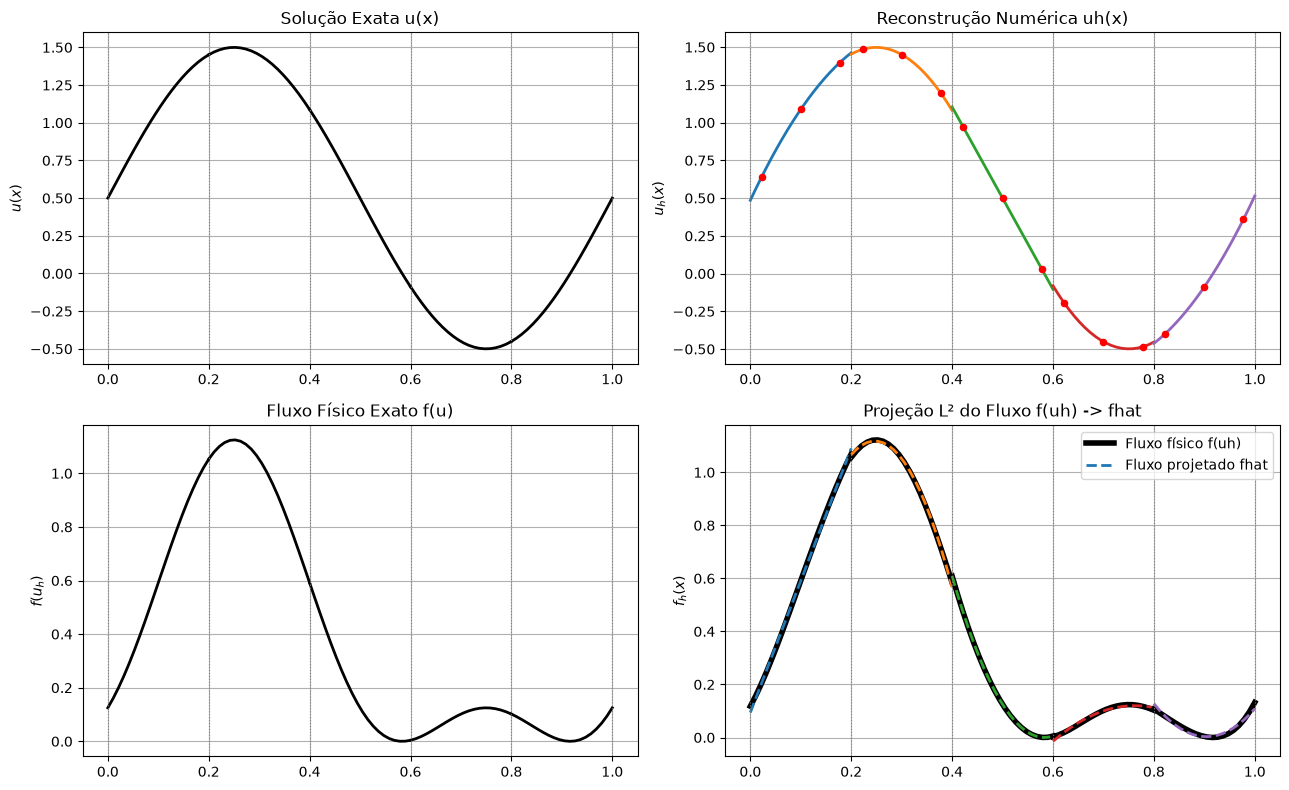

In [5]:
##################### Plots #####################
fig, ax = plt.subplots(2, 2, figsize=(13,8))

# Pontos de alta resolução para visualização
Nplot = 20
xplot_ref = np.linspace(-1.0, 1.0, Nplot)
psi_plot = LegendreBasis(N, xplot_ref)

for k in range(K):

    xa = VX[k]
    xb = VX[k+1]

    x_plot = 0.5 * (xb - xa) * xplot_ref + 0.5 * (xa + xb) # Domínio físico para visualização    
    x_quad = 0.5 * (xb - xa) * xi + 0.5 * (xa + xb)        # Pontos de quadratura reais do elemento

    u_exact = InviscidBurgers(x_plot) # Solução exata de u
    f_exact = BurgersFlux(u_exact)             # Calcula o fluxo físico EXATO usando u(x)

    uh = psi_plot @ uhat_burg[:, k:k+1]        # Reconstrução de u
    fh = BurgersFlux(uh)                       # Fluxo físico (usado para a projeção)
    fh_proj = psi_plot @ fhat_burg[:, k:k+1]   # Fluxo projetado


    # Solução exata de u
    ax[0, 0].plot(x_plot, u_exact, color="black", lw=2)

    # Reconstrução de u
    ax[0, 1].plot(x_plot, uh, lw=2)
    ax[0, 1].scatter(x_quad, InviscidBurgers(x_quad), color="red", s=20, zorder=5) # pontos da quadratura

    # Plot 3 FLUXO EXATO contínuo
    ax[1, 0].plot(x_plot, f_exact, color="black", lw=2)

    # Plot 4: Comparação (o que o solver viu vs o que ele projetou)
    ax[1, 1].plot(x_plot,fh,'k',lw=4,label="Fluxo físico f(uh)" if k == 0 else None)

    ax[1, 1].plot(x_plot,fh_proj,"--",lw=2,label="Fluxo projetado fhat" if k == 0 else None)

# Desenha as interfaces dos elementos e configura eixos
for eixo in ax.ravel():
    for x in VX:
        eixo.axvline(x, color="gray", ls=":", lw=0.8)
    eixo.grid(True)

ax[0,0].set_title("Solução Exata u(x)")
ax[0,1].set_title("Reconstrução Numérica uh(x)")
ax[1,0].set_title("Fluxo Físico Exato f(u)")
ax[1,1].set_title("Projeção L² do Fluxo f(uh) -> fhat")

ax[0, 0].set_ylabel(r"$u(x)$")
ax[0, 1].set_ylabel(r"$u_h(x)$")
ax[1, 0].set_ylabel(r"$f(u_h)$")
ax[1, 1].set_ylabel(r"$f_h(x)$")

ax[1, 1].legend()

plt.tight_layout()
plt.show()

## **Extra: Fluxos Reais em Cenários Específicos** 

Os problemas que estudamos costumam apresentar comportamentos físicos muito diferentes entre si e, como esperado, cada um tende a seguir um formalismo próprio. No entanto, o nosso solver foi construído de forma modular: toda a física do problema fica contida no **vetor de fluxo** $f(u)$. 

Como completude ao contexto de **Projeção de Fluxos**, alguns dos problemas clássicos da engenharia e da física serão apresentados na sequência. Veremos a equação diferencial associada a cada um e como o seu fluxo é traduzido para o código.

### 1. Equação de Burgers (Invíscida)
A Equação de Burgers modela a propagação e a formação de ondas de choque em um fluido sem viscosidade. A lei de conservação é dada por:

$$\frac{\partial u}{\partial t} + \frac{\partial}{\partial x} \left( \frac{u^2}{2} \right) = 0$$

Onde o fluxo é claramente identificado como $f(u) = \frac{u^2}{2}$.

### 2. Equação de Allen-Cahn
Originalmente desenvolvida para modelar a separação de fases em ligas metálicas, esta equação é um excelente exemplo de como a escolha do fluxo define a física (podendo agir como Burgers, difusão pura ou sistema Cahn-Hilliard). A forma genérica cúbica é frequentemente descrita por:

$$\frac{\partial u}{\partial t} + \frac{\partial}{\partial x} \left( u^3 - u \right) = \epsilon \frac{\partial^2 u}{\partial x^2}$$

Aqui, a função de fluxo que entra na nossa projeção pode variar dependendo do estado do material, sendo $f(u) = u^3 - u$ o caso cúbico.

### 3. Shallow-Water (Águas Rasas)
Utilizado para simular o escoamento em rios, canais e tsunamis. O sistema acopla duas variáveis: a altura da coluna d'água ($h$) e a velocidade ($u$). O sistema conservativo clássico (Tipo 1) é:

$$\frac{\partial}{\partial t} \begin{bmatrix} h \\ u \end{bmatrix} + \frac{\partial}{\partial x} \begin{bmatrix} hu \\ \frac{u^2}{2} + gh \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

**Shallow-Water com Atrito (Tipo 2):** Em cenários mais realistas, o fluxo se mantém o mesmo, mas adicionamos um **termo fonte** $S(U)$ no lado direito da igualdade para contabilizar o atrito do fundo (usando equações de Blasius ou Churchill) e a inclinação do terreno.

### 4. Equações de Euler (Dinâmica dos Fluidos)
Modelam o escoamento de gases compressíveis (como a aerodinâmica de um caça supersônico). Trabalhamos com variáveis conservativas: densidade ($\rho$), momento ($\rho u$) e energia total ($E$).

$$\frac{\partial}{\partial t} \begin{bmatrix} \rho \\ \rho u \\ E \end{bmatrix} + \frac{\partial}{\partial x} \begin{bmatrix} \rho u \\ \frac{(\rho u)^2}{\rho} + p \\ \frac{(E+p)\rho u}{\rho} \end{bmatrix} = 0$$

Neste caso, o vetor de fluxo lida simultaneamente com a conservação de massa, quantidade de movimento e energia.

---

### Implementação: Gerenciador de Fluxos

O objetivo é termos um repositório Python que contenha todos esses fluxos para que eles possam ser acessados pelo nosso solver de forma automática. 

Para isso, organizamos as funções em uma classe chamada `PhysicsFluxes`. Isso permite que o código principal selecione dinamicamente qual física simular, mantendo o processo de projeção genérico!



In [6]:
import numpy as np
import math

class PhysicsFluxes:
    """
    Biblioteca de fluxos físicos para o solver espectral.
    Fornece as avaliações de f(uh) e termos fonte S(uh) nos pontos de integração.
    """

    @staticmethod
    def Burgers(uh, **kwargs):
        return 0.5 * uh**2

    @staticmethod
    def AllenCahn(uh, ac_type='Burgers', **kwargs):
        if ac_type == 'Burgers':
            return (uh**2) / 2.0
        elif ac_type == 'Cubic':
            return uh**3 - uh
        elif ac_type == 'PureDiff':
            return np.zeros_like(uh)
        else:
            beta_fe = 0.5
            return -beta_fe * uh

    @staticmethod
    def ShallowWater(uh_list, gravity=9.81, **kwargs):
        hh, uh = uh_list[0], uh_list[1]
        hf = hh * uh
        uf = gravity * hh + (uh**2) / 2.0
        return [hf, uf]

    @staticmethod
    def ShallowWaterFrictionSource(uh_list, visc=1e-6, eps=1e-3, gravity=9.81, inc=0.0, **kwargs):
        hh, uh = uh_list[0], uh_list[1]
        
        # Cálculo do Reynolds
        Re_matrix = 4 * uh * hh / visc
        Re_flat = Re_matrix.flatten()
        hh_flat = hh.flatten()
        uh_flat = uh.flatten()
        Cf_flat = np.zeros_like(Re_flat)
        
        for i, re in enumerate(Re_flat):
            if uh_flat[i] == 0.:
                cf = 0.
            else:
                if re <= 2000.:
                    cf = 16.0 / re  # Equação de Blasius
                else:
                    # Equação de Churchill
                    D = 4 * hh_flat[i]
                    B = (37530.0 / re)**16
                    A = (2.457 * np.log( ((7.0/re)**0.9 + 0.27*(eps/D))**-1 ))**16
                    cf = 2 * ((8.0/re)**12 + (A + B)**-1.5)**(1/12)
            Cf_flat[i] = cf
            
        Cf = Cf_flat.reshape(hh.shape)
        
        # Termo fonte final (atrito + inclinação)
        us = -Cf * (uh**2) / (2 * hh) + gravity * math.sin(inc)
        return [np.zeros_like(us), us] # Conservação de massa não tem fonte, só a de momento

    @staticmethod
    def Euler(uh_list, gamma=1.4, **kwargs):
        rho, rhou, Ener = uh_list[0], uh_list[1], uh_list[2]
        
        # Equação de Estado para Gás Ideal (Cálculo da Pressão)
        pres = (gamma - 1.0) * (Ener - 0.5 * (rhou**2) / rho)
        
        rhof = rhou.copy()
        rhouf = (rhou**2) / rho + pres
        Enerf = (Ener + pres) * rhou / rho
        
        return [rhof, rhouf, Enerf]

# Exemplo de como o Solver chamaria o fluxo:
# fluxos = PhysicsFluxes.ShallowWater([h_fisico, u_fisico], gravity=9.8)